# Low-token query-plan config selector

Minimal benchmark for choosing the best LLM query-plan configuration with low spend.

The notebook runs in this order:
1. Build tiny representative query-plan tasks.
2. Sweep tasks per prompt from 8 to 64.
3. Pick the best tasks-per-prompt for each provider/model/reasoning-effort.
4. Sweep parallel requests starting at 4 using that chosen task size.
5. Produce a final recommended config and supporting metrics.

Supported providers:
- OpenRouter, optionally routed to Cerebras.
- Direct Cerebras via the OpenAI-compatible chat completions endpoint.


In [1]:
from __future__ import annotations

import json
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pprint import pprint
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen


def env_first(*names: str) -> str:
    for name in names:
        value = os.environ.get(name, "").strip()
        if value:
            return value
    return ""


def env_list(name: str, default: list[str]) -> list[str]:
    raw = os.environ.get(name, "").strip()
    if not raw:
        return default
    return [item.strip() for item in raw.split(",") if item.strip()]

## Knobs

Defaults are intentionally small. Increase them only after the first benchmark is clean.

In [2]:
RUN_LIVE_CALLS = True

# Keep output bounded per task while still allowing the 64-task prompt to complete.
MAX_TOKENS_FLOOR = 192
MAX_TOKENS_PER_TASK = 18
MAX_TOKENS_CAP = 1536
TEMPERATURE = 0.0
TIMEOUT_SECONDS = 90

TASK_COUNTS = [8, 16, 32, 64]
PARALLEL_REQUESTS = [4, 8, 16]
REASONING_EFFORTS = ["medium"]

# Leave as None to use the task-size recommendation from the first sweep.
PARALLEL_TASKS_PER_REQUEST_OVERRIDE = None

# Add comma-separated env vars to test several models without editing the notebook:
# OPENROUTER_MODELS="openai/gpt-oss-120b,meta-llama/llama-3.1-8b-instruct"
# CEREBRAS_MODELS="gpt-oss-120b,llama3.1-8b"
OPENROUTER_MODELS = env_list("OPENROUTER_MODELS", [os.environ.get("OPENROUTER_MODEL", "openai/gpt-oss-120b")])
CEREBRAS_MODELS = env_list("CEREBRAS_MODELS", [os.environ.get("CEREBRAS_MODEL", "gpt-oss-120b")])

# OpenRouter can route to Cerebras while still using the OpenRouter endpoint.
OPENROUTER_ROUTE_PROVIDER = os.environ.get("OPENROUTER_ROUTE_PROVIDER", "cerebras").strip()
OPENROUTER_ALLOW_FALLBACKS = os.environ.get("OPENROUTER_ALLOW_FALLBACKS", "true").casefold() not in {"0", "false", "no"}

PROVIDERS = ["openrouter", "cerebras"]

## Tiny synthetic tasks

These are intentionally short so prompt cost stays low while still exercising typo handling, locations, companies, and ambiguous names.

In [3]:
BASE_TINY_TASKS = [
    {"id": "t01", "m": "San Joséé", "ctx": "Costa Rica city"},
    {"id": "t02", "m": "Peten", "ctx": "Guatemala department"},
    {"id": "t03", "m": "JPMorgan Chase & Co..", "ctx": "bank company USA"},
    {"id": "t04", "m": "Royal Dutch Shhelll", "ctx": "oil and gas Netherlands"},
    {"id": "t05", "m": "Wacco Lake", "ctx": "Texas reservoir"},
    {"id": "t06", "m": "Queen Elizabeeth II", "ctx": "monarch person"},
    {"id": "t07", "m": "Calabarzon", "ctx": "Philippines region"},
    {"id": "t08", "m": "ExxonMMobil", "ctx": "oil company"},
    {"id": "t09", "m": "UBS", "ctx": "Switzerland finance"},
    {"id": "t10", "m": "Jordanelle Reservoir", "ctx": "Utah lake"},
    {"id": "t11", "m": "Caaguazu", "ctx": "Paraguay department"},
    {"id": "t12", "m": "Andalusia", "ctx": "Spain region"},
    {"id": "t13", "m": "Puebla", "ctx": "Mexico state"},
    {"id": "t14", "m": "Veraguas", "ctx": "Panama province"},
    {"id": "t15", "m": "Twin Buttes Reservoir", "ctx": "Texas lake"},
    {"id": "t16", "m": "American International Groupp", "ctx": "insurance USA"},
]


def make_tiny_tasks(total: int = 128) -> list[dict]:
    tasks = []
    for index in range(total):
        base = BASE_TINY_TASKS[index % len(BASE_TINY_TASKS)]
        tasks.append({"id": f"t{index + 1:03d}", "m": base["m"], "ctx": base["ctx"]})
    return tasks


TINY_TASKS = make_tiny_tasks(128)

TINY_TASKS[:3]

[{'id': 't001', 'm': 'San Joséé', 'ctx': 'Costa Rica city'},
 {'id': 't002', 'm': 'Peten', 'ctx': 'Guatemala department'},
 {'id': 't003', 'm': 'JPMorgan Chase & Co..', 'ctx': 'bank company USA'}]

## Request builder

The prompt is much smaller than production. Use it for provider/model capacity testing, not final retrieval-quality evaluation.

In [4]:
SYSTEM_PROMPT = "Return compact JSON only. Build recall-oriented entity search queries. No explanations."


def provider_cases() -> list[dict]:
    cases = []
    if "openrouter" in PROVIDERS:
        for model in OPENROUTER_MODELS:
            cases.append(
                {
                    "provider": "openrouter",
                    "model": model,
                    "endpoint": os.environ.get("OPENROUTER_CHAT_URL", "https://openrouter.ai/api/v1/chat/completions"),
                    "api_key": env_first("OPENROUTER_API_KEY", "LLM_API_KEY"),
                    "extra_headers": {
                        "HTTP-Referer": os.environ.get("OPENROUTER_SITE_URL", "http://localhost"),
                        "X-Title": os.environ.get("OPENROUTER_APP_NAME", "low-token-query-plan-benchmark"),
                    },
                }
            )
    if "cerebras" in PROVIDERS:
        for model in CEREBRAS_MODELS:
            cases.append(
                {
                    "provider": "cerebras",
                    "model": model,
                    "endpoint": os.environ.get("CEREBRAS_CHAT_URL", "https://api.cerebras.ai/v1/chat/completions"),
                    "api_key": env_first("CEREBRAS_API_KEY"),
                    "extra_headers": {},
                }
            )
    return cases


def max_tokens_for(tasks: list[dict]) -> int:
    return min(MAX_TOKENS_CAP, max(MAX_TOKENS_FLOOR, len(tasks) * MAX_TOKENS_PER_TASK))


def build_body(case: dict, tasks: list[dict], reasoning_effort: str) -> dict:
    body = {
        "model": case["model"],
        "temperature": TEMPERATURE,
        "max_tokens": max_tokens_for(tasks),
        "response_format": {"type": "json_object"},
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": json.dumps(
                    {
                        "tasks": tasks,
                        "schema": {"tasks": [{"id": "same", "q": "short search query", "type": "PERSON|ORG|LOC|OTHER"}]},
                    },
                    separators=(",", ":"),
                    ensure_ascii=False,
                ),
            },
        ],
    }
    if case["provider"] == "openrouter":
        body["include_reasoning"] = False
        body["reasoning"] = {"effort": reasoning_effort}
        if OPENROUTER_ROUTE_PROVIDER:
            body["provider"] = {"order": [OPENROUTER_ROUTE_PROVIDER], "allow_fallbacks": OPENROUTER_ALLOW_FALLBACKS}
    elif case["provider"] == "cerebras":
        body["reasoning_effort"] = reasoning_effort
    return body


def request_size(case: dict, tasks: list[dict], reasoning_effort: str) -> int:
    return len(json.dumps(build_body(case, tasks, reasoning_effort), ensure_ascii=False))


for case in provider_cases():
    print(case["provider"], case["model"], "key_set=", bool(case["api_key"]))
    print("  1 task chars:", request_size(case, TINY_TASKS[:1], REASONING_EFFORTS[0]))
    print("  8 task chars:", request_size(case, TINY_TASKS[:8], REASONING_EFFORTS[0]))

openrouter openai/gpt-oss-120b key_set= True
  1 task chars: 594
  8 task chars: 1100
cerebras gpt-oss-120b key_set= True
  1 task chars: 492
  8 task chars: 998


## Caller and parser

In [5]:
def extract_json_object(text: str) -> dict:
    stripped = (text or "").strip()
    if not stripped:
        return {}
    try:
        parsed = json.loads(stripped)
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        start = stripped.find("{")
        end = stripped.rfind("}")
        if start >= 0 and end > start:
            try:
                parsed = json.loads(stripped[start : end + 1])
                return parsed if isinstance(parsed, dict) else {}
            except json.JSONDecodeError:
                return {}
    return {}


def message_content_text(content) -> str:
    if content is None:
        return ""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        return "".join(str(item.get("text") or item.get("content") or "") if isinstance(item, dict) else str(item) for item in content)
    return str(content)


def score_response(content_text: str, tasks: list[dict]) -> dict:
    parsed = extract_json_object(content_text)
    returned = parsed.get("tasks") if isinstance(parsed.get("tasks"), list) else []
    requested_ids = {task["id"] for task in tasks}
    returned_ids = {str(task.get("id")) for task in returned if isinstance(task, dict) and task.get("id") is not None}
    usable = [task for task in returned if isinstance(task, dict) and task.get("id") in requested_ids and str(task.get("q") or "").strip()]
    return {
        "returned": len(returned),
        "usable": len(usable),
        "missing": len(requested_ids - returned_ids),
        "unknown": len(returned_ids - requested_ids),
        "content_chars": len(content_text or ""),
    }


def call_case(case: dict, tasks: list[dict], reasoning_effort: str) -> dict:
    if not case["api_key"]:
        return {
            "provider": case["provider"],
            "model": case["model"],
            "tasks": len(tasks),
            "reasoning_effort": reasoning_effort,
            "error": "missing_api_key",
        }
    body = build_body(case, tasks, reasoning_effort)
    headers = {
        "Authorization": f"Bearer {case['api_key']}",
        "Content-Type": "application/json",
        **case.get("extra_headers", {}),
    }
    started = time.monotonic()
    try:
        request = Request(case["endpoint"], data=json.dumps(body).encode("utf-8"), headers=headers, method="POST")
        with urlopen(request, timeout=TIMEOUT_SECONDS) as response:
            raw = (response.read() or b"{}").decode("utf-8", errors="replace")
            payload = json.loads(raw)
            message = (payload.get("choices") or [{}])[0].get("message") or {}
            content_text = message_content_text(message.get("content"))
            usage = payload.get("usage") or {}
            details = usage.get("completion_tokens_details") or {}
            scored = score_response(content_text, tasks)
            return {
                "provider": case["provider"],
                "model": case["model"],
                "tasks": len(tasks),
                "reasoning_effort": reasoning_effort,
                "http_status": getattr(response, "status", None),
                "seconds": round(time.monotonic() - started, 3),
                "request_chars": len(json.dumps(body, ensure_ascii=False)),
                "prompt_tokens": usage.get("prompt_tokens"),
                "completion_tokens": usage.get("completion_tokens"),
                "reasoning_tokens": details.get("reasoning_tokens"),
                "response_id": payload.get("id"),
                "error": None,
                **scored,
            }
    except HTTPError as exc:
        detail = exc.read().decode("utf-8", errors="replace")
        error = f"HTTP {exc.code}: {detail[:240]}"
    except (URLError, TimeoutError, json.JSONDecodeError) as exc:
        error = str(exc)
    return {
        "provider": case["provider"],
        "model": case["model"],
        "tasks": len(tasks),
        "reasoning_effort": reasoning_effort,
        "seconds": round(time.monotonic() - started, 3),
        "request_chars": len(json.dumps(body, ensure_ascii=False)),
        "error": error,
    }

## Step 1: task-size sweep

This finds how many query-plan tasks each model/provider can reliably answer in one prompt. The recommendation prefers complete responses first, then lower tokens per usable task, then higher usable tasks per second.


In [6]:
task_sweep_results = []

if RUN_LIVE_CALLS:
    for case in provider_cases():
        for task_count in TASK_COUNTS:
            for effort in REASONING_EFFORTS:
                result = call_case(case, TINY_TASKS[:task_count], effort)
                task_sweep_results.append(result)
                pprint(result)
else:
    print("Live calls disabled. Set RUN_LIVE_CALLS = True to run the task-size sweep.")

{'completion_tokens': 192,
 'content_chars': 0,
 'error': None,
 'http_status': 200,
 'missing': 8,
 'model': 'openai/gpt-oss-120b',
 'prompt_tokens': 284,
 'provider': 'openrouter',
 'reasoning_effort': 'medium',
 'reasoning_tokens': 189,
 'request_chars': 1100,
 'response_id': 'gen-1782944420-vmrxEVkWSpyglvTlcvuD',
 'returned': 0,
 'seconds': 0.759,
 'tasks': 8,
 'unknown': 0,
 'usable': 0}
{'completion_tokens': 288,
 'content_chars': 0,
 'error': None,
 'http_status': 200,
 'missing': 16,
 'model': 'openai/gpt-oss-120b',
 'prompt_tokens': 419,
 'provider': 'openrouter',
 'reasoning_effort': 'medium',
 'reasoning_tokens': 285,
 'request_chars': 1649,
 'response_id': 'gen-1782944421-lnyy7PzrIVcjyjp73AyU',
 'returned': 0,
 'seconds': 0.459,
 'tasks': 16,
 'unknown': 0,
 'usable': 0}
{'completion_tokens': 576,
 'content_chars': 0,
 'error': None,
 'http_status': 200,
 'missing': 32,
 'model': 'openai/gpt-oss-120b',
 'prompt_tokens': 698,
 'provider': 'openrouter',
 'reasoning_effort': '

## Step 2: choose tasks per prompt

The analysis below picks a task count per provider/model/reasoning-effort. A row is considered successful only when it has no error and returns a usable plan for every requested task.


In [7]:
def case_key_from_result(item: dict) -> tuple[str, str, str]:
    return (str(item.get("provider")), str(item.get("model")), str(item.get("reasoning_effort")))


def case_key(case: dict, reasoning_effort: str) -> tuple[str, str, str]:
    return (str(case.get("provider")), str(case.get("model")), str(reasoning_effort))


def add_task_metrics(item: dict) -> dict:
    row = dict(item)
    requested = int(row.get("tasks") or 0)
    usable = int(row.get("usable") or 0)
    missing = int(row.get("missing") or requested)
    seconds = float(row.get("seconds") or 0)
    prompt_tokens = row.get("prompt_tokens") or 0
    completion_tokens = row.get("completion_tokens") or 0
    total_tokens = prompt_tokens + completion_tokens if prompt_tokens or completion_tokens else None
    row["success"] = not row.get("error") and requested > 0 and missing == 0 and usable == requested
    row["success_rate"] = round(usable / requested, 3) if requested else 0
    row["usable_per_second"] = round(usable / max(seconds, 0.001), 3) if usable else 0
    row["tokens_per_usable_task"] = round(total_tokens / usable, 2) if total_tokens and usable else None
    row["request_chars_per_task"] = round((row.get("request_chars") or 0) / max(requested, 1), 1)
    return row


def choose_task_counts(results: list[dict]) -> tuple[list[dict], dict[tuple[str, str, str], int]]:
    rows = [add_task_metrics(item) for item in results]
    grouped: dict[tuple[str, str, str], list[dict]] = {}
    for row in rows:
        grouped.setdefault(case_key_from_result(row), []).append(row)

    recommendations = []
    best_by_case = {}
    for key, group in grouped.items():
        successful = [row for row in group if row["success"]]
        if successful:
            with_tokens = [row for row in successful if row["tokens_per_usable_task"] is not None]
            if with_tokens:
                min_tokens = min(row["tokens_per_usable_task"] for row in with_tokens)
                efficient = [row for row in with_tokens if row["tokens_per_usable_task"] <= min_tokens * 1.20]
                chosen = sorted(efficient, key=lambda row: (-row["tasks"], -row["usable_per_second"]))[0]
                rationale = "largest complete task count within 20% of the lowest token cost per usable task"
            else:
                chosen = sorted(successful, key=lambda row: (-row["tasks"], -row["usable_per_second"]))[0]
                rationale = "largest complete task count; token usage was not returned by provider"
        else:
            chosen = sorted(group, key=lambda row: (-row["success_rate"], row.get("error") is not None, -row.get("tasks", 0)))[0]
            rationale = "no fully complete response; chose highest success rate for follow-up debugging"

        best_by_case[key] = int(chosen.get("tasks") or min(TASK_COUNTS))
        recommendations.append({**chosen, "rationale": rationale})
    return recommendations, best_by_case


task_recommendations, BEST_TASKS_BY_CASE = choose_task_counts(task_sweep_results)
print("Task-size recommendations:")
pprint(task_recommendations)

if task_recommendations:
    print("\nBest task counts by provider/model/reasoning_effort:")
    pprint(BEST_TASKS_BY_CASE)
else:
    print("No live task-size results yet. Run the previous cell with RUN_LIVE_CALLS = True.")


Task-size recommendations:
[{'completion_tokens': 1152,
  'content_chars': 0,
  'error': None,
  'http_status': 200,
  'missing': 64,
  'model': 'openai/gpt-oss-120b',
  'prompt_tokens': 1256,
  'provider': 'openrouter',
  'rationale': 'no fully complete response; chose highest success rate for '
               'follow-up debugging',
  'reasoning_effort': 'medium',
  'reasoning_tokens': 1149,
  'request_chars': 5013,
  'request_chars_per_task': 78.3,
  'response_id': 'gen-1782944422-rd9mvaJMsQJ1mDdNT5gR',
  'returned': 0,
  'seconds': 1.175,
  'success': False,
  'success_rate': 0.0,
  'tasks': 64,
  'tokens_per_usable_task': None,
  'unknown': 0,
  'usable': 0,
  'usable_per_second': 0},
 {'error': 'HTTP 403: error code: 1010\n',
  'model': 'gpt-oss-120b',
  'provider': 'cerebras',
  'rationale': 'no fully complete response; chose highest success rate for '
               'follow-up debugging',
  'reasoning_effort': 'medium',
  'request_chars': 4911,
  'request_chars_per_task': 76.7,


## Step 3: parallel request sweep

For each provider/model/reasoning-effort, this uses the recommended task count from Step 2 unless `PARALLEL_TASKS_PER_REQUEST_OVERRIDE` is set. It then tests parallelism from 4 upward.


In [8]:
PARALLEL_REASONING_EFFORT = REASONING_EFFORTS[0]
parallel_results = []


def chunks(items: list[dict], size: int) -> list[list[dict]]:
    return [items[index : index + size] for index in range(0, len(items), size)]


def tasks_per_request_for(case: dict, reasoning_effort: str) -> int:
    if PARALLEL_TASKS_PER_REQUEST_OVERRIDE is not None:
        return int(PARALLEL_TASKS_PER_REQUEST_OVERRIDE)
    return int(BEST_TASKS_BY_CASE.get(case_key(case, reasoning_effort), min(TASK_COUNTS)))


if RUN_LIVE_CALLS:
    for case in provider_cases():
        tasks_per_request = tasks_per_request_for(case, PARALLEL_REASONING_EFFORT)
        task_pool = make_tiny_tasks(max(PARALLEL_REQUESTS) * tasks_per_request)
        prepared_batches = chunks(task_pool, tasks_per_request)
        for parallelism in PARALLEL_REQUESTS:
            batches = prepared_batches[:parallelism]
            started = time.monotonic()
            with ThreadPoolExecutor(max_workers=parallelism) as executor:
                futures = [executor.submit(call_case, case, batch, PARALLEL_REASONING_EFFORT) for batch in batches]
                children = [future.result() for future in as_completed(futures)]
            aggregate = {
                "provider": case["provider"],
                "model": case["model"],
                "reasoning_effort": PARALLEL_REASONING_EFFORT,
                "parallelism": parallelism,
                "tasks_per_request": tasks_per_request,
                "requests": len(children),
                "requested_tasks": sum(item.get("tasks", 0) for item in children),
                "usable_tasks": sum(item.get("usable", 0) for item in children),
                "missing_tasks": sum(item.get("missing", 0) for item in children),
                "wall_seconds": round(time.monotonic() - started, 3),
                "errors": [item.get("error") for item in children if item.get("error")],
                "children": children,
            }
            parallel_results.append(aggregate)
            pprint(aggregate)
else:
    print("Live calls disabled. Set RUN_LIVE_CALLS = True to run the parallel sweep.")


{'children': [{'completion_tokens': 1152,
               'content_chars': 1413,
               'error': None,
               'http_status': 200,
               'missing': 64,
               'model': 'openai/gpt-oss-120b',
               'prompt_tokens': 1256,
               'provider': 'openrouter',
               'reasoning_effort': 'medium',
               'reasoning_tokens': 699,
               'request_chars': 5013,
               'response_id': 'gen-1782944424-3ClqO3GivwGlshNqRpWP',
               'returned': 0,
               'seconds': 0.818,
               'tasks': 64,
               'unknown': 0,
               'usable': 0},
              {'completion_tokens': 1152,
               'content_chars': 1592,
               'error': None,
               'http_status': 200,
               'missing': 64,
               'model': 'openai/gpt-oss-120b',
               'prompt_tokens': 1256,
               'provider': 'openrouter',
               'reasoning_effort': 'medium',
            

## Step 4: final recommendation

The final selector prefers stable configurations first: no child request errors and no missing tasks. Among stable rows for a provider/model, it chooses the smallest parallelism that reaches at least 90% of that case's best observed throughput, which avoids recommending unnecessary concurrency when throughput has already flattened.


In [9]:
def add_parallel_metrics(item: dict) -> dict:
    row = dict(item)
    requested = int(row.get("requested_tasks") or 0)
    usable = int(row.get("usable_tasks") or 0)
    wall_seconds = float(row.get("wall_seconds") or 0)
    child_tokens = 0
    child_token_count_available = False
    child_seconds = []
    for child in row.get("children") or []:
        prompt_tokens = child.get("prompt_tokens") or 0
        completion_tokens = child.get("completion_tokens") or 0
        if prompt_tokens or completion_tokens:
            child_token_count_available = True
            child_tokens += prompt_tokens + completion_tokens
        if child.get("seconds") is not None:
            child_seconds.append(float(child["seconds"]))
    row["success"] = not row.get("errors") and requested > 0 and int(row.get("missing_tasks") or 0) == 0 and usable == requested
    row["success_rate"] = round(usable / requested, 3) if requested else 0
    row["usable_per_second"] = round(usable / max(wall_seconds, 0.001), 3) if usable else 0
    row["requests_per_second"] = round((row.get("requests") or 0) / max(wall_seconds, 0.001), 3)
    row["tokens_per_usable_task"] = round(child_tokens / usable, 2) if child_token_count_available and usable else None
    row["avg_child_seconds"] = round(sum(child_seconds) / len(child_seconds), 3) if child_seconds else None
    return row


def choose_parallel_configs(results: list[dict]) -> tuple[list[dict], dict | None]:
    rows = [add_parallel_metrics(item) for item in results]
    grouped: dict[tuple[str, str, str, int], list[dict]] = {}
    for row in rows:
        key = (row["provider"], row["model"], row.get("reasoning_effort"), row["tasks_per_request"])
        grouped.setdefault(key, []).append(row)

    per_case = []
    for key, group in grouped.items():
        stable = [row for row in group if row["success"]]
        if stable:
            max_throughput = max(row["usable_per_second"] for row in stable)
            near_best = [row for row in stable if row["usable_per_second"] >= max_throughput * 0.90]
            chosen = sorted(near_best, key=lambda row: (row["parallelism"], row["tokens_per_usable_task"] or 10**9))[0]
            rationale = "smallest stable parallelism within 90% of best observed throughput"
        else:
            chosen = sorted(group, key=lambda row: (-row["success_rate"], len(row.get("errors") or []), -row["usable_per_second"]))[0]
            rationale = "no stable parallel setting; chose highest success rate for debugging"
        per_case.append({**chosen, "rationale": rationale})

    stable_recommendations = [row for row in per_case if row["success"]]
    if stable_recommendations:
        overall = sorted(
            stable_recommendations,
            key=lambda row: (-row["usable_per_second"], row["tokens_per_usable_task"] or 10**9, row["parallelism"]),
        )[0]
    else:
        overall = sorted(per_case, key=lambda row: (-row["success_rate"], -row["usable_per_second"]))[0] if per_case else None
    return per_case, overall


parallel_recommendations, overall_recommendation = choose_parallel_configs(parallel_results)

print("Per-provider/model parallel recommendations:")
pprint(parallel_recommendations)

print("\nOverall recommended config:")
pprint(overall_recommendation)

if overall_recommendation:
    print("\nUse this config:")
    print(f"provider={overall_recommendation['provider']}")
    print(f"model={overall_recommendation['model']}")
    print(f"reasoning_effort={overall_recommendation.get('reasoning_effort')}")
    print(f"tasks_per_prompt={overall_recommendation['tasks_per_request']}")
    print(f"parallel_requests={overall_recommendation['parallelism']}")
    print(f"observed_usable_tasks_per_second={overall_recommendation['usable_per_second']}")
    print(f"tokens_per_usable_task={overall_recommendation.get('tokens_per_usable_task')}")
else:
    print("No recommendation yet. Run the task-size and parallel sweep cells first.")


Per-provider/model parallel recommendations:
[{'avg_child_seconds': 1.078,
  'children': [{'completion_tokens': 1152,
                'content_chars': 1413,
                'error': None,
                'http_status': 200,
                'missing': 64,
                'model': 'openai/gpt-oss-120b',
                'prompt_tokens': 1256,
                'provider': 'openrouter',
                'reasoning_effort': 'medium',
                'reasoning_tokens': 699,
                'request_chars': 5013,
                'response_id': 'gen-1782944424-3ClqO3GivwGlshNqRpWP',
                'returned': 0,
                'seconds': 0.818,
                'tasks': 64,
                'unknown': 0,
                'usable': 0},
               {'completion_tokens': 1152,
                'content_chars': 1592,
                'error': None,
                'http_status': 200,
                'missing': 64,
                'model': 'openai/gpt-oss-120b',
                'prompt_tokens': 1256,

## Visualizations

These plots are meant to make the choice easy to inspect:
- Task-size sweep: completeness and throughput by tasks per prompt.
- Parallel sweep: throughput by parallel request count.
- Efficiency tradeoff: throughput versus token cost per usable task when token usage is returned.

The selected overall recommendation is marked with a star on the parallel-throughput chart.


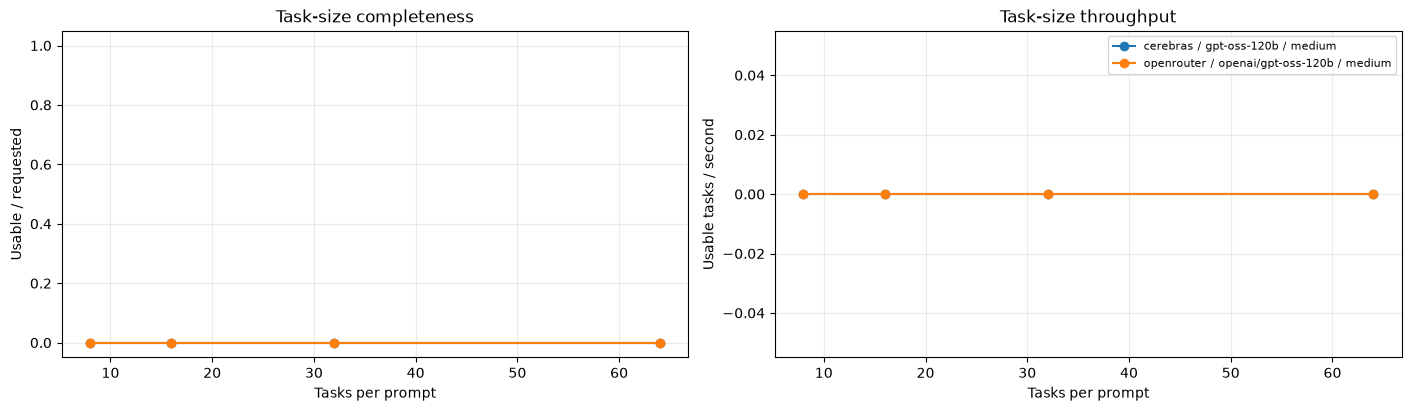

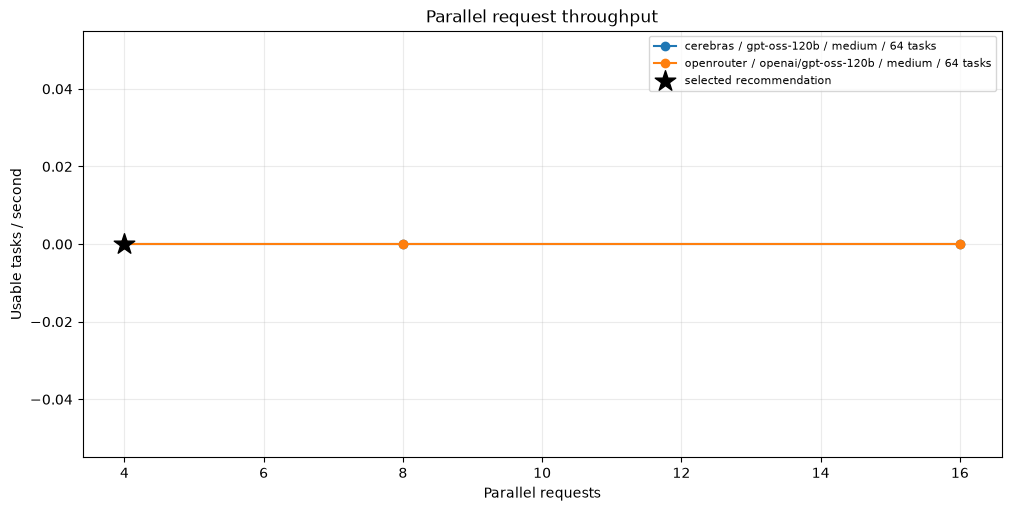

No token usage data to plot yet. Some providers may omit usage fields.


In [10]:
import matplotlib.pyplot as plt


def label_for(row: dict) -> str:
    return f"{row.get('provider')} / {row.get('model')} / {row.get('reasoning_effort')}"


def plot_task_sweep(results: list[dict]) -> None:
    rows = [add_task_metrics(item) for item in results]
    if not rows:
        print("No task sweep results to plot yet.")
        return
    labels = sorted({label_for(row) for row in rows})
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    for label in labels:
        group = sorted([row for row in rows if label_for(row) == label], key=lambda row: row["tasks"])
        x = [row["tasks"] for row in group]
        axes[0].plot(x, [row["success_rate"] for row in group], marker="o", label=label)
        axes[1].plot(x, [row["usable_per_second"] for row in group], marker="o", label=label)
    axes[0].set_title("Task-size completeness")
    axes[0].set_xlabel("Tasks per prompt")
    axes[0].set_ylabel("Usable / requested")
    axes[0].set_ylim(-0.05, 1.05)
    axes[0].grid(True, alpha=0.25)
    axes[1].set_title("Task-size throughput")
    axes[1].set_xlabel("Tasks per prompt")
    axes[1].set_ylabel("Usable tasks / second")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(loc="best", fontsize=8)
    plt.show()


def plot_parallel_sweep(results: list[dict], recommendation: dict | None) -> None:
    rows = [add_parallel_metrics(item) for item in results]
    if not rows:
        print("No parallel sweep results to plot yet.")
        return
    labels = sorted({label_for(row) + f" / {row.get('tasks_per_request')} tasks" for row in rows})
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    for label in labels:
        group = sorted(
            [row for row in rows if label_for(row) + f" / {row.get('tasks_per_request')} tasks" == label],
            key=lambda row: row["parallelism"],
        )
        ax.plot([row["parallelism"] for row in group], [row["usable_per_second"] for row in group], marker="o", label=label)
    if recommendation:
        ax.scatter(
            [recommendation["parallelism"]],
            [recommendation["usable_per_second"]],
            marker="*",
            s=240,
            color="black",
            label="selected recommendation",
            zorder=5,
        )
    ax.set_title("Parallel request throughput")
    ax.set_xlabel("Parallel requests")
    ax.set_ylabel("Usable tasks / second")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)
    plt.show()


def plot_efficiency_tradeoff(task_results: list[dict], parallel_results: list[dict]) -> None:
    task_rows = [add_task_metrics(item) for item in task_results]
    parallel_rows = [add_parallel_metrics(item) for item in parallel_results]
    rows = [row for row in task_rows + parallel_rows if row.get("tokens_per_usable_task") is not None and row.get("usable_per_second")]
    if not rows:
        print("No token usage data to plot yet. Some providers may omit usage fields.")
        return
    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    for row in rows:
        marker = "s" if "parallelism" in row else "o"
        size = 90 if row.get("success") else 45
        ax.scatter(row["tokens_per_usable_task"], row["usable_per_second"], s=size, marker=marker, alpha=0.75)
        label = f"{row.get('provider')} {row.get('tasks') or row.get('tasks_per_request')}t"
        if "parallelism" in row:
            label += f" x{row.get('parallelism')}"
        ax.annotate(label, (row["tokens_per_usable_task"], row["usable_per_second"]), fontsize=7, xytext=(4, 3), textcoords="offset points")
    ax.set_title("Efficiency tradeoff")
    ax.set_xlabel("Tokens per usable task, lower is better")
    ax.set_ylabel("Usable tasks / second, higher is better")
    ax.grid(True, alpha=0.25)
    plt.show()


plot_task_sweep(task_sweep_results)
plot_parallel_sweep(parallel_results, overall_recommendation)
plot_efficiency_tradeoff(task_sweep_results, parallel_results)


## Optional: save benchmark results

This writes a local JSON artifact with raw results and recommendations. It does not include API keys.


In [11]:
SAVE_RESULTS = False

if SAVE_RESULTS:
    output = {
        "task_counts": TASK_COUNTS,
        "parallel_requests": PARALLEL_REQUESTS,
        "reasoning_efforts": REASONING_EFFORTS,
        "task_sweep_results": task_sweep_results,
        "task_recommendations": task_recommendations,
        "parallel_results": parallel_results,
        "parallel_recommendations": parallel_recommendations,
        "overall_recommendation": overall_recommendation,
    }
    path = f"low_token_provider_benchmark_{int(time.time())}.json"
    with open(path, "w", encoding="utf-8") as handle:
        json.dump(output, handle, indent=2, ensure_ascii=False)
    print(path)
else:
    print("Set SAVE_RESULTS = True to write the benchmark results JSON.")


Set SAVE_RESULTS = True to write the benchmark results JSON.
